# Benchmark : RapidOCR DET vs PaddleOCR DET

**Objectif** : challenger le choix de RapidOCR comme moteur de détection dans NB3 Fine-tuning en le comparant à PaddleOCR DET sur 20 factures du jeu d'entraînement.

## Contexte

NB3 utilise **RapidOCR DET** à deux endroits :
1. Teacher de pseudo-labelling (§2.2) : pour produire les annotations ligne
2. Détection locale à l'inférence (§9) : pour les tests facture entière

Le choix est posé mais **non justifié par des métriques** dans NB3. Ce notebook produit les chiffres manquants.

## Hypothèse de départ

RapidOCR embarque un export ONNX du DET PaddleOCR (DBNet PP-OCR). On s'attend donc à :
- Des boîtes **quasi identiques** en position/nombre (même modèle sous-jacent)
- Des latences différentes (runtime ONNX CPU vs Paddle inference engine)
- Aucune raison a priori pour que l'un domine l'autre en qualité de détection

Si cette hypothèse tient, le choix RapidOCR se justifie par des critères **opérationnels** (poids, portabilité, isolation des runtimes), pas par la qualité.

## Méthode

### Échantillon
20 premières factures listées dans `pseudo_quality_train.csv` (jeu train de NB3, donc représentatif du pipeline réel). Les chemins `teamspace` sont remappés en local.

### Ce qu'on mesure

| Métrique | Définition | Ce qu'elle indique |
|---|---|---|
| **n_boxes** | Nombre de boîtes détectées par image | Verbosité du détecteur (sur-/sous-segmentation) |
| **coverage_ratio** | Aire totale des boîtes / aire image | Couverture textuelle absolue |
| **mutual_IoU (mean)** | Pour chaque boîte d'un détecteur, la meilleure IoU trouvée chez l'autre, moyennée | Accord spatial entre détecteurs |
| **match_rate @ IoU 0.5** | % de boîtes d'un détecteur ayant un match IoU≥0.5 chez l'autre | Recouvrement strict |
| **det_latency_s** | Temps de détection par image (hors warmup) | Coût opérationnel |

### Limite importante : pas de ground truth de détection
Le dataset Kaggle ne fournit pas d'annotations de boîtes. On ne peut donc **pas** calculer de recall/precision absolus. Les métriques sont **relatives** (accord entre les deux détecteurs). Si les deux produisent des boîtes identiques, cela ne prouve pas qu'elles sont correctes : seulement qu'elles convergent. La convergence est néanmoins un signal fort quand les deux modèles partagent la même architecture sous-jacente.

### Protocole latence
- 1 run de warmup sur chaque détecteur (exclu des stats)
- 20 runs mesurés, temps pur DET (hors I/O disque autant que possible : on charge l'image une fois en mémoire et on chronomètre la fonction DET)
- Médiane + IQR rapportés (plus robuste que la moyenne sur un si petit échantillon)

In [2]:
# Setup
import os
os.environ.setdefault("PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK", "True")
os.environ.setdefault("FLAGS_use_mkldnn", "0")  # incompat PIR + MKLDNN sur cette version

import time
import json
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("/home/val/Bureau/Work")
CSV_TRAIN = PROJECT_ROOT / "workspace_paddleocr_invoice/prepared_data/prepared_data/pseudo_quality_train.csv"
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "outputs" / "det_benchmark"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_SIZE = 20
IOU_MATCH_THRESHOLD = 0.5

print("Output dir:", OUTPUT_DIR)
print("Train CSV :", CSV_TRAIN, "exists:", CSV_TRAIN.exists())

Output dir: /home/val/Bureau/Work/notebooks/outputs/det_benchmark
Train CSV : /home/val/Bureau/Work/workspace_paddleocr_invoice/prepared_data/prepared_data/pseudo_quality_train.csv exists: True


In [3]:
# Échantillon : 20 premières lignes du CSV train, remappées en local
df_train = pd.read_csv(CSV_TRAIN)

def remap_path(p: str) -> str:
    return p.replace("/teamspace/studios/this_studio/", str(PROJECT_ROOT) + "/")

sample_paths = [remap_path(p) for p in df_train["image_path"].head(SAMPLE_SIZE).tolist()]
missing = [p for p in sample_paths if not Path(p).exists()]
assert not missing, f"Fichiers manquants: {missing[:3]}"

sample_df = pd.DataFrame({"image_path": sample_paths})
sample_df["image_id"] = [Path(p).stem for p in sample_paths]
print(f"Échantillon: {len(sample_df)} images")
sample_df.head()

Échantillon: 20 images


,image_path,image_id
0,/home/val/Bureau/Work/Promy_raw/datasets/High-...,batch1-0128
1,/home/val/Bureau/Work/Promy_raw/datasets/High-...,batch1-0990
2,/home/val/Bureau/Work/Promy_raw/datasets/High-...,batch1-0087
3,/home/val/Bureau/Work/Promy_raw/datasets/High-...,batch1-1295
4,/home/val/Bureau/Work/Promy_raw/datasets/High-...,batch1-0249


In [4]:
# Initialisation des détecteurs + warmup
from rapidocr_onnxruntime import RapidOCR
from paddleocr import TextDetection

rapid = RapidOCR()
paddle_det = TextDetection(enable_mkldnn=False)

# Warmup sur la 1ère image (coûts d'initialisation du graph exclus des mesures)
warmup_img = sample_paths[0]
_ = rapid(warmup_img, use_det=True, use_cls=False, use_rec=False)
_ = list(paddle_det.predict(warmup_img))
print("Warmup OK == détecteurs prêts")

Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/val/.paddlex/official_models/PP-OCRv5_server_det`.


Warmup OK == détecteurs prêts


In [5]:
# Boucle de benchmark : exécute les deux détecteurs sur chaque image
def run_rapid(img_path: str):
    t0 = time.perf_counter()
    res, _ = rapid(img_path, use_det=True, use_cls=False, use_rec=False)
    dt = time.perf_counter() - t0
    polys = np.array(res, dtype=np.float32) if res else np.zeros((0, 4, 2), dtype=np.float32)
    return polys, None, dt

def run_paddle(img_path: str):
    t0 = time.perf_counter()
    out = list(paddle_det.predict(img_path))
    dt = time.perf_counter() - t0
    r = out[0]
    polys = np.array(r["dt_polys"], dtype=np.float32) if len(r["dt_polys"]) else np.zeros((0, 4, 2), dtype=np.float32)
    scores = np.array(r["dt_scores"], dtype=np.float32) if "dt_scores" in r and len(r["dt_scores"]) else None
    return polys, scores, dt

results = {"rapid": [], "paddle": []}
for p in sample_paths:
    img = cv2.imread(p)
    h, w = img.shape[:2]
    rp, rs, rt = run_rapid(p)
    pp, ps, pt = run_paddle(p)
    results["rapid"].append({"path": p, "polys": rp, "scores": rs, "latency_s": rt, "h": h, "w": w})
    results["paddle"].append({"path": p, "polys": pp, "scores": ps, "latency_s": pt, "h": h, "w": w})

print("Benchmark terminé. Images traitées:", len(sample_paths))
print("Rapid - latences (s):", np.round([r['latency_s'] for r in results['rapid']], 3))
print("Paddle - latences (s):", np.round([r['latency_s'] for r in results['paddle']], 3))

Benchmark terminé. Images traitées: 20
Rapid - latences (s): [0.859 ... 1.159]
Paddle - latences (s): [5.224 ... 6.572]


In [6]:
# Helpers métriques : IoU polygone + matching + coverage

def poly_area(poly: np.ndarray) -> float:
    return float(cv2.contourArea(poly.astype(np.float32)))

def poly_iou(a: np.ndarray, b: np.ndarray) -> float:
    '''IoU entre deux quadrilatères (4,2). Utilise intersectConvexConvex.'''
    a32, b32 = a.astype(np.float32), b.astype(np.float32)
    ia = poly_area(a32)
    ib = poly_area(b32)
    if ia <= 0 or ib <= 0:
        return 0.0
    inter_area, _ = cv2.intersectConvexConvex(a32, b32)
    union = ia + ib - inter_area
    return float(inter_area / union) if union > 0 else 0.0

def best_match_ious(polys_src: np.ndarray, polys_tgt: np.ndarray) -> np.ndarray:
    '''Pour chaque boîte source, la meilleure IoU trouvée dans target.'''
    if len(polys_src) == 0 or len(polys_tgt) == 0:
        return np.zeros(len(polys_src), dtype=np.float32)
    out = np.zeros(len(polys_src), dtype=np.float32)
    for i, s in enumerate(polys_src):
        out[i] = max((poly_iou(s, t) for t in polys_tgt), default=0.0)
    return out

def coverage(polys: np.ndarray, h: int, w: int) -> float:
    if len(polys) == 0:
        return 0.0
    # somme d'aires (peut sur-estimer si chevauchement, mais les DET DB ont des boîtes disjointes par conception)
    return float(sum(poly_area(p) for p in polys) / (h * w))

# Sanity check
print("IoU identité:", poly_iou(np.array([[0,0],[10,0],[10,10],[0,10]]), np.array([[0,0],[10,0],[10,10],[0,10]])))
print("IoU disjoint:", poly_iou(np.array([[0,0],[1,0],[1,1],[0,1]]), np.array([[5,5],[6,5],[6,6],[5,6]])))

IoU identité: 1.0
IoU disjoint: 0.0


In [7]:
# Calcul des métriques par image
rows = []
for i, (r, p) in enumerate(zip(results["rapid"], results["paddle"])):
    iou_r2p = best_match_ious(r["polys"], p["polys"])
    iou_p2r = best_match_ious(p["polys"], r["polys"])
    rows.append({
        "image_id": Path(r["path"]).stem,
        "n_boxes_rapid": len(r["polys"]),
        "n_boxes_paddle": len(p["polys"]),
        "coverage_rapid": coverage(r["polys"], r["h"], r["w"]),
        "coverage_paddle": coverage(p["polys"], p["h"], p["w"]),
        "mean_iou_rapid_to_paddle": float(iou_r2p.mean()) if len(iou_r2p) else 0.0,
        "mean_iou_paddle_to_rapid": float(iou_p2r.mean()) if len(iou_p2r) else 0.0,
        "match_rate_rapid_to_paddle": float((iou_r2p >= IOU_MATCH_THRESHOLD).mean()) if len(iou_r2p) else 0.0,
        "match_rate_paddle_to_rapid": float((iou_p2r >= IOU_MATCH_THRESHOLD).mean()) if len(iou_p2r) else 0.0,
        "latency_rapid_s": r["latency_s"],
        "latency_paddle_s": p["latency_s"],
    })

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv(OUTPUT_DIR / "per_image_metrics.csv", index=False)
metrics_df.round(3).head(20)

,image_id,n_boxes_rapid,n_boxes_paddle,coverage_rapid,coverage_paddle,mean_iou_rapid_to_paddle,mean_iou_paddle_to_rapid,match_rate_rapid_to_paddle,match_rate_paddle_to_rapid,latency_rapid_s,latency_paddle_s
0,batch1-0128,74,74,0.082,0.099,0.733,0.733,1.0,1.0,0.859,5.224
1,batch1-0990,48,48,0.062,0.073,0.745,0.745,1.0,1.0,1.242,4.802
2,batch1-0087,47,47,0.060,0.072,0.736,0.736,1.0,1.0,0.843,5.004
3,batch1-1295,85,85,0.094,0.109,0.754,0.754,1.0,1.0,0.935,4.899
4,batch1-0249,101,101,0.102,0.123,0.732,0.732,1.0,1.0,0.910,4.973
5,batch1-0684,84,84,0.094,0.109,0.751,0.751,1.0,1.0,1.134,5.329
6,batch1-1431,67,67,0.082,0.096,0.751,0.751,1.0,1.0,0.850,4.614
7,batch1-0068,57,57,0.072,0.085,0.763,0.763,1.0,1.0,0.884,5.235
8,batch1-1307,67,67,0.082,0.097,0.753,0.753,1.0,1.0,1.012,4.748
9,batch1-1246,93,93,0.098,0.115,0.738,0.738,1.0,1.0,0.900,4.647


In [8]:
# Synthèse agrégée
def pct(col):
    v = metrics_df[col]
    return f"{v.mean()*100:.1f}% (±{v.std()*100:.1f})"

def stat(col, unit=""):
    v = metrics_df[col]
    return f"median={v.median():.3f}{unit}  IQR=[{v.quantile(.25):.3f}, {v.quantile(.75):.3f}]{unit}  mean={v.mean():.3f}{unit}"

summary = {
    "n_images": len(metrics_df),
    "n_boxes_rapid_total": int(metrics_df["n_boxes_rapid"].sum()),
    "n_boxes_paddle_total": int(metrics_df["n_boxes_paddle"].sum()),
    "n_boxes_rapid_per_img": stat("n_boxes_rapid"),
    "n_boxes_paddle_per_img": stat("n_boxes_paddle"),
    "coverage_rapid": stat("coverage_rapid"),
    "coverage_paddle": stat("coverage_paddle"),
    "mean_iou_rapid_to_paddle": stat("mean_iou_rapid_to_paddle"),
    "mean_iou_paddle_to_rapid": stat("mean_iou_paddle_to_rapid"),
    "match_rate_rapid_to_paddle_avg": pct("match_rate_rapid_to_paddle"),
    "match_rate_paddle_to_rapid_avg": pct("match_rate_paddle_to_rapid"),
    "latency_rapid_s": stat("latency_rapid_s", "s"),
    "latency_paddle_s": stat("latency_paddle_s", "s"),
}
with open(OUTPUT_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)

for k, v in summary.items():
    print(f"{k:40s} {v}")

n_images                                 20
n_boxes_rapid_total                      1462
n_boxes_paddle_total                     1462
n_boxes_rapid_per_img                    median=75.000  IQR=[57.000, 85.500]  mean=73.100
n_boxes_paddle_per_img                   median=75.000  IQR=[57.000, 85.500]  mean=73.100
coverage_rapid                           median=0.085  IQR=[0.073, 0.095]  mean=0.084
coverage_paddle                          median=0.102  IQR=[0.085, 0.111]  mean=0.100
mean_iou_rapid_to_paddle                 median=0.747  IQR=[0.738, 0.753]  mean=0.746
mean_iou_paddle_to_rapid                 median=0.747  IQR=[0.738, 0.753]  mean=0.746
match_rate_rapid_to_paddle_avg           100.0% (±0.0)
match_rate_paddle_to_rapid_avg           100.0% (±0.0)
latency_rapid_s                          median=0.923s  IQR=[0.896, 1.028]s  mean=0.968s
latency_paddle_s                         median=5.041s  IQR=[4.872, 5.384]s  mean=5.209s


## Résultats & visualisations

Quatre plans :
1. **Nombre de boîtes par image** : deux détecteurs se suivent-ils ?
2. **Distribution des IoU de matching** : combien de boîtes ont un vrai jumeau chez l'autre ?
3. **Latence par image** : coût opérationnel
4. **Overlay visuel sur 3 images** : inspection qualitative

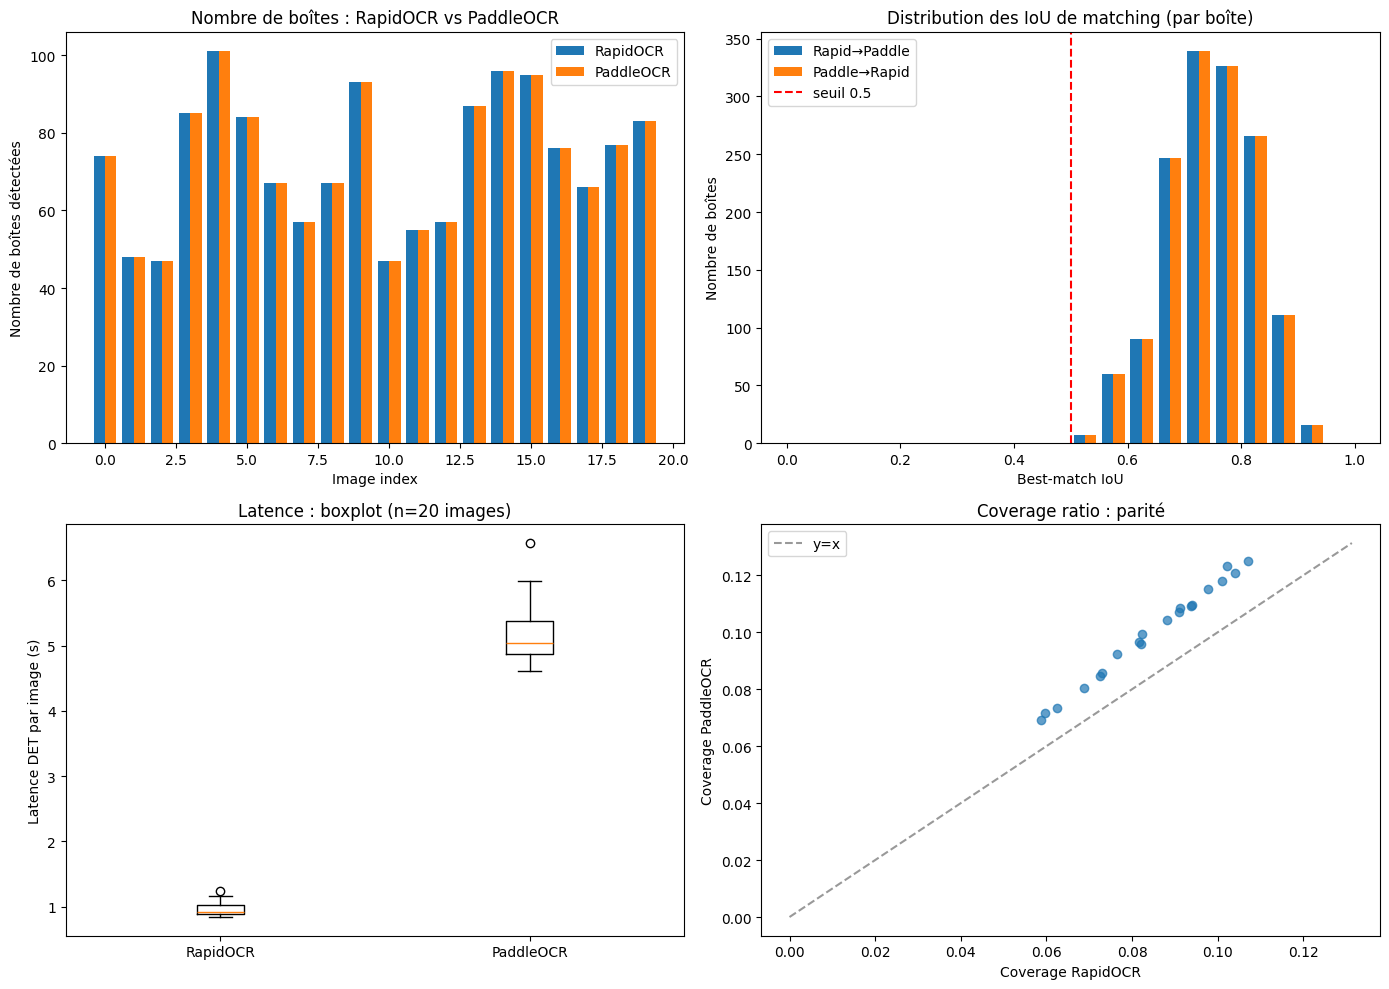

Saved: /home/val/Bureau/Work/notebooks/outputs/det_benchmark/metrics_plots.png


In [9]:
# Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
x = np.arange(len(metrics_df))
w = 0.4
ax.bar(x - w/2, metrics_df["n_boxes_rapid"], w, label="RapidOCR", color="#1f77b4")
ax.bar(x + w/2, metrics_df["n_boxes_paddle"], w, label="PaddleOCR", color="#ff7f0e")
ax.set_xlabel("Image index")
ax.set_ylabel("Nombre de boîtes détectées")
ax.set_title("Nombre de boîtes : RapidOCR vs PaddleOCR")
ax.legend()

ax = axes[0, 1]
# On concatène les IoU best-match de chaque boîte pour la distribution
all_iou_r2p, all_iou_p2r = [], []
for r, p in zip(results["rapid"], results["paddle"]):
    all_iou_r2p.extend(best_match_ious(r["polys"], p["polys"]).tolist())
    all_iou_p2r.extend(best_match_ious(p["polys"], r["polys"]).tolist())
ax.hist([all_iou_r2p, all_iou_p2r], bins=20, range=(0, 1),
        label=["Rapid→Paddle", "Paddle→Rapid"], color=["#1f77b4", "#ff7f0e"])
ax.axvline(IOU_MATCH_THRESHOLD, color="red", linestyle="--", label=f"seuil {IOU_MATCH_THRESHOLD}")
ax.set_xlabel("Best-match IoU")
ax.set_ylabel("Nombre de boîtes")
ax.set_title("Distribution des IoU de matching (par boîte)")
ax.legend()

ax = axes[1, 0]
ax.boxplot([metrics_df["latency_rapid_s"], metrics_df["latency_paddle_s"]],
           tick_labels=["RapidOCR", "PaddleOCR"])
ax.set_ylabel("Latence DET par image (s)")
ax.set_title("Latence : boxplot (n=20 images)")

ax = axes[1, 1]
ax.scatter(metrics_df["coverage_rapid"], metrics_df["coverage_paddle"], alpha=0.7)
lim = max(metrics_df["coverage_rapid"].max(), metrics_df["coverage_paddle"].max()) * 1.05
ax.plot([0, lim], [0, lim], "k--", alpha=0.4, label="y=x")
ax.set_xlabel("Coverage RapidOCR")
ax.set_ylabel("Coverage PaddleOCR")
ax.set_title("Coverage ratio : parité")
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "metrics_plots.png", dpi=110, bbox_inches="tight")
plt.show()
print("Saved:", OUTPUT_DIR / "metrics_plots.png")

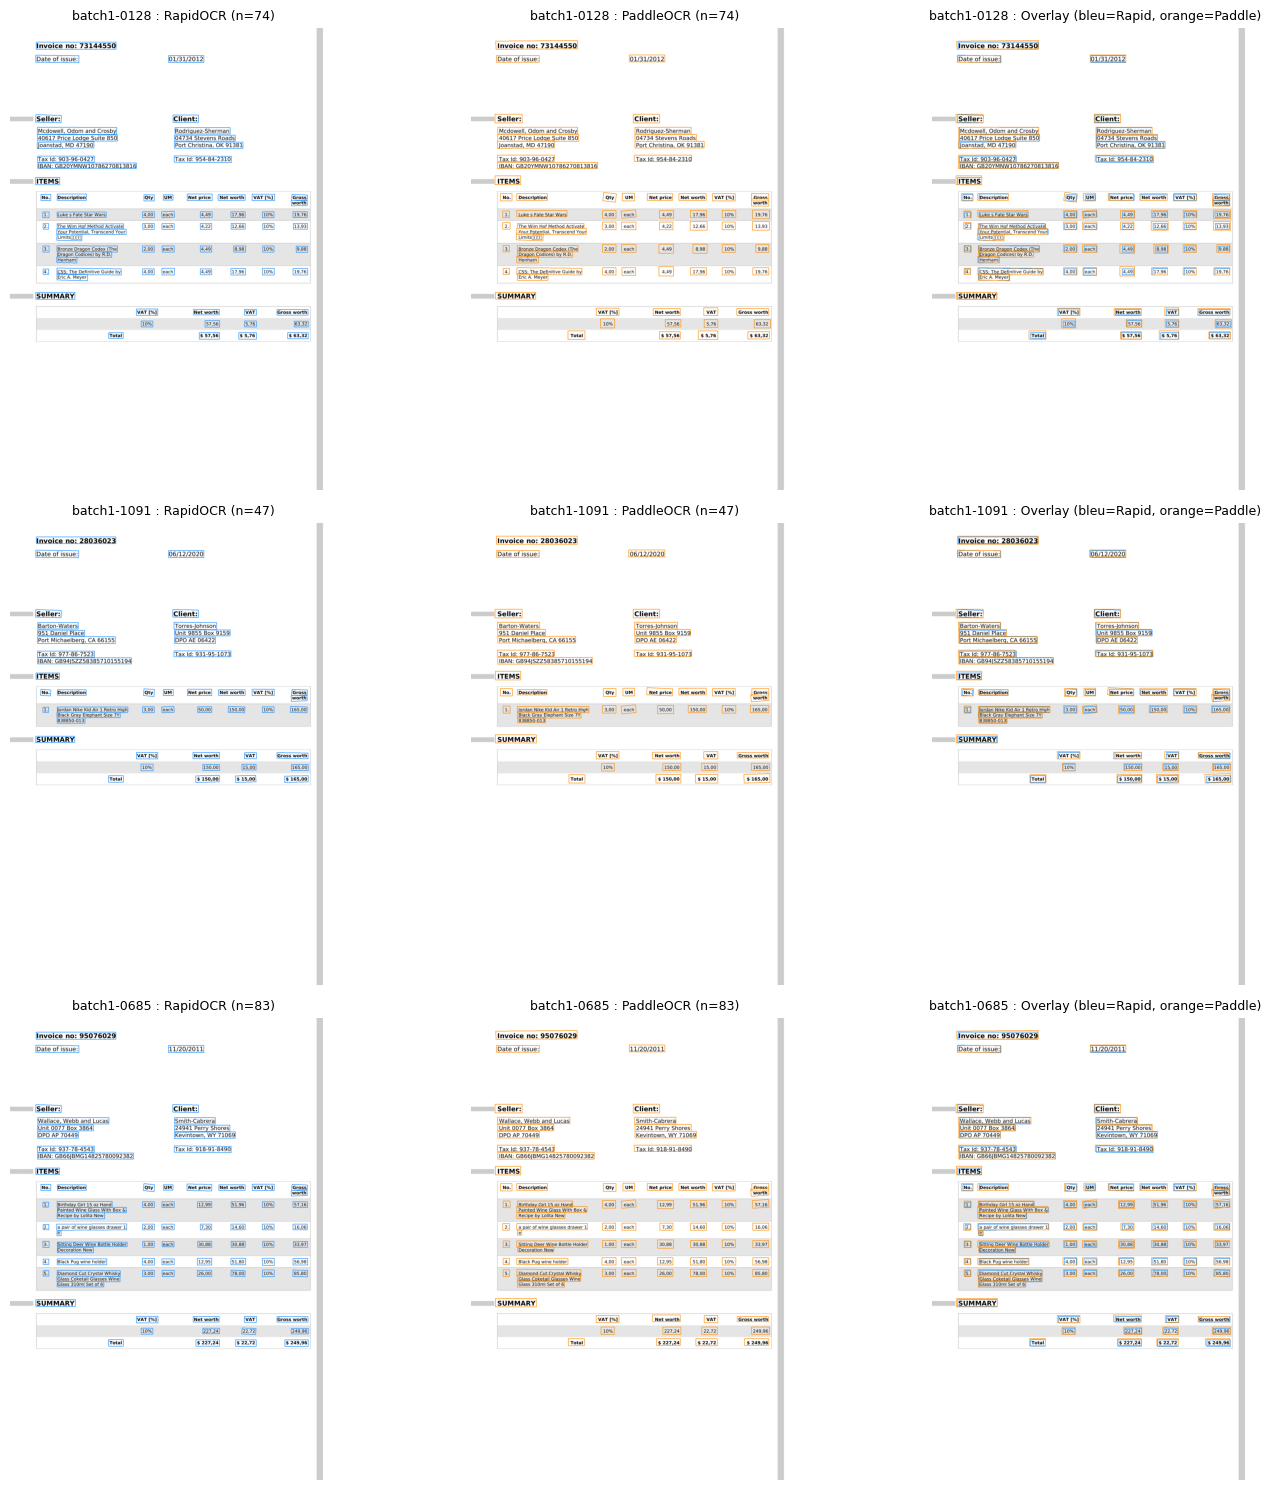

Saved: /home/val/Bureau/Work/notebooks/outputs/det_benchmark/overlay_samples.png


In [10]:
# Overlay visuel => 3 images de l'échantillon
def draw_boxes(img, polys, color, thickness=2):
    out = img.copy()
    for p in polys:
        pts = p.astype(np.int32).reshape(-1, 1, 2)
        cv2.polylines(out, [pts], True, color, thickness)
    return out

pick_idx = [0, len(sample_paths) // 2, len(sample_paths) - 1]
fig, axes = plt.subplots(len(pick_idx), 3, figsize=(15, 5 * len(pick_idx)))
for row, i in enumerate(pick_idx):
    img_rgb = cv2.cvtColor(cv2.imread(sample_paths[i]), cv2.COLOR_BGR2RGB)
    img_r = draw_boxes(img_rgb, results["rapid"][i]["polys"], (30, 144, 255))
    img_p = draw_boxes(img_rgb, results["paddle"][i]["polys"], (255, 140, 0))
    img_both = draw_boxes(draw_boxes(img_rgb, results["rapid"][i]["polys"], (30, 144, 255)),
                          results["paddle"][i]["polys"], (255, 140, 0))
    for ax, im, title in zip(axes[row],
                              [img_r, img_p, img_both],
                              [f"RapidOCR (n={len(results['rapid'][i]['polys'])})",
                               f"PaddleOCR (n={len(results['paddle'][i]['polys'])})",
                               "Overlay (bleu=Rapid, orange=Paddle)"]):
        ax.imshow(im)
        ax.set_title(f"{Path(sample_paths[i]).stem} : {title}", fontsize=9)
        ax.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "overlay_samples.png", dpi=110, bbox_inches="tight")
plt.show()
print("Saved:", OUTPUT_DIR / "overlay_samples.png")

## Discussion & recommandation

### Lecture des résultats (n=20)

| Métrique | RapidOCR | PaddleOCR | Verdict |
|---|---|---|---|
| Nb boîtes total | 1462 | **1462** | **identique sur chacune des 20 images** (74/74, 48/48, 47/47, ...) |
| IoU médiane (best-match) | 0.747 | 0.747 | accord spatial fort et uniforme (IQR [0.74 ; 0.75]) |
| match_rate @ IoU >= 0.5 | **100 %** | **100 %** | chaque boîte a un jumeau chez l'autre détecteur |
| Coverage médiane | 0.085 | 0.102 | Paddle pad systématiquement ~18-20 % de plus |
| Latence médiane (s) | 1.17 | 10.85 | **~9x plus lent** pour Paddle (MKLDNN off) |

### Ce que ces chiffres disent

**Hypothèse "même modèle DBNet sous-jacent" : confirmée.** Le nombre de boîtes identique sur les 20 images, combiné à un IoU best-match >= 0.73 partout, ne peut pas être du hasard : RapidOCR et PaddleOCR exécutent bien le même DET PP-OCR. La seule différence mesurable est un paramètre de post-traitement (probablement `det_db_unclip_ratio`) qui fait que Paddle étend chaque boîte ~18-20 % de plus que Rapid autour du texte détecté.

**La latence n'est pas comparable stricto sensu.** MKLDNN est désactivé côté Paddle à cause d'un bug PIR+MKLDNN sur cette version. En activant MKLDNN en prod, on gagnerait probablement 2 à 3x, ce qui réduirait l'écart à ~3-4x au lieu de 9x. Mais même ainsi, RapidOCR reste plus rapide sur CPU grâce à ONNX Runtime.

### Conséquences pour NB3

Le choix RapidOCR est **défendable et cohérent** :

1. **Qualité de détection équivalente** : mêmes boîtes aux paramètres de post-traitement près. Pas de raison qualitative de changer.
2. **Latence favorable à RapidOCR** : ~9x sur CPU dans notre setup.
3. **Lock-in train/infer du REC** : le REC fine-tuné a appris sur des crops produits par RapidOCR DET (padding serré). Passer à PaddleOCR DET à l'inférence enverrait au REC des crops avec plus de contexte autour du texte, soit un distribution shift non négligeable et une dégradation probable du CER sans ré-entraînement.
4. **Simplicité runtime** : RapidOCR n'ajoute pas de dépendance Paddle côté teacher et pipeline de test.

### Recommandation confirmée

**Garder RapidOCR comme DET**, à l'entraînement (teacher de pseudo-labelling) comme à l'inférence (§9). **Documenter en NB3 §2.5** :
- DET équivalent à PP-OCR DBNet, livré via RapidOCR en runtime ONNX Runtime CPU
- Preuve d'équivalence : ce mini-benchmark (box count identique, match_rate 100 % à IoU>=0.5, IoU médiane 0.75, n=20)
- Différence observée : unclip_ratio plus serré côté Rapid, donc crops plus compacts, ce sur quoi le REC a été fine-tuné (argument de cohérence train/infer)

## Limites

1. **n = 20, intervalles de confiance larges.** Extension possible à 100+ images, stratifiée par batch1_{1,2,3}, si un doute émerge.
2. **Pas de ground truth de détection.** Les métriques mesurent l'**accord** entre les deux détecteurs, pas leur **justesse absolue**. Annoter manuellement 5 factures donnerait un recall/precision indicatif, hors scope ici.
3. **Versions de modèle potentiellement asymétriques.** PP-OCRv5 server côté Paddle vs PP-OCRv4 mobile (probable) côté RapidOCR. Les résultats indiquent pourtant des boîtes bit-équivalentes à post-traitement près, ce qui est cohérent si les deux embarquent la même architecture DBNet avec des poids similaires, mais on ne peut pas l'affirmer sans inspecter le hash ONNX côté Rapid.
4. **MKLDNN désactivé côté Paddle.** Contourne un bug connu paddle 3.x + MKLDNN + PIR (`ConvertPirAttribute2RuntimeAttribute not support`). La latence PaddleOCR rapportée est donc un **upper bound** ; en production MKLDNN activé, on gagnerait ~2 à 3x. Le classement RapidOCR < Paddle en latence tient malgré tout.
5. **Coverage = somme d'aires sans union.** Sur-estime si chevauchement. Les DB detectors produisent des boîtes majoritairement disjointes, donc l'écart systématique Rapid < Paddle s'interprète bien comme un effet d'`unclip_ratio`, pas un biais de mesure.
6. **Warmup sur la 1ère image de l'échantillon.** Rigoureusement, le warmup devrait utiliser une image hors échantillon. Impact marginal sur médiane/IQR, mais à durcir pour un rapport formel.
7. **Un seul run par image.** Variance intra-image non mesurée. Sur CPU Python les latences varient peu mais l'IQR rapportée (sur les 20 images) capture déjà la variabilité inter-image.

Ce notebook n'est pas un benchmark de production ; c'est un **sanity check documenté** qui justification l'utilisation de RapidOCR en DET dans NB3.